In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [59]:
import qnas_config as cfg
import torch
from util import plot_training_history

In [60]:
phase = 'evolution'
experiment_path = 'my_exp_config2'
config_file = 'config_files/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict

params = config.train_spec

net_list = ['conv_3_1_256','no_op', 'conv_3_1_128', 'no_op','no_op','no_op',
            'conv_3_1_64','conv_3_1_64','no_op','conv_3_1_256','conv_3_1_256',
            'max_pool_2_2', 'conv_3_1_128', 'no_op','no_op','no_op','no_op','no_op',
            'max_pool_2_2', 'conv_3_1_128']

In [61]:
# create a list with all available cuda devices
device_list = [f'cuda:{i}' for i in range(torch.cuda.device_count())]
device_list

['cuda:0', 'cuda:1', 'cuda:2']

In [62]:
params['device'] = device_list[1]
params['device']

'cuda:1'

In [63]:
from cnn.train import fitness_calculation
from cnn.input import cifar10_info

data = {
    "num_classes": 10,
}
params['limit_data'] = True

# AdamW

In [64]:
results_dict_2 = fitness_calculation(id_num="job_1", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
results_dict_2["best_accuracy"]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training Fitness Scheme:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch [2/300] - Training loss: 4.103820897638798 - Validation loss: 4.3641886711120605 - Validation accuracy: 22.7%
Epoch [3/300] - Training loss: 3.1372204646468163 - Validation loss: 3.2454447746276855 - Validation accuracy: 29.2%
Epoch [4/300] - Training loss: 2.7419899478554726 - Validation loss: 3.6815028190612793 - Validation accuracy: 33.0%
Epoch [5/300] - Training loss: 2.7321327328681946 - Validation loss: 2.1890194416046143 - Validation accuracy: 33.8%
Epoch [6/300] - Training loss: 2.6771382242441177 - Validation loss: 2.3648812770843506 - Validation accuracy: 38.8%
Epoch [7/300] - Training loss: 2.352639853954315 - Validation loss: 2.140894889831543 - Validation accuracy: 39.7%
Epoch [8/300] - Training loss: 2.3853892758488655 - Validation loss: 1.8145084381103516 - Validation accuracy: 41.5%
Epoch [9/300] - Training loss: 2.277000892907381 - Validation loss: 1.8884996175765991 - Validation accuracy: 41.2%
Epoch [10/300] - Training loss: 2.300791047513485 - Validation loss:

77.0

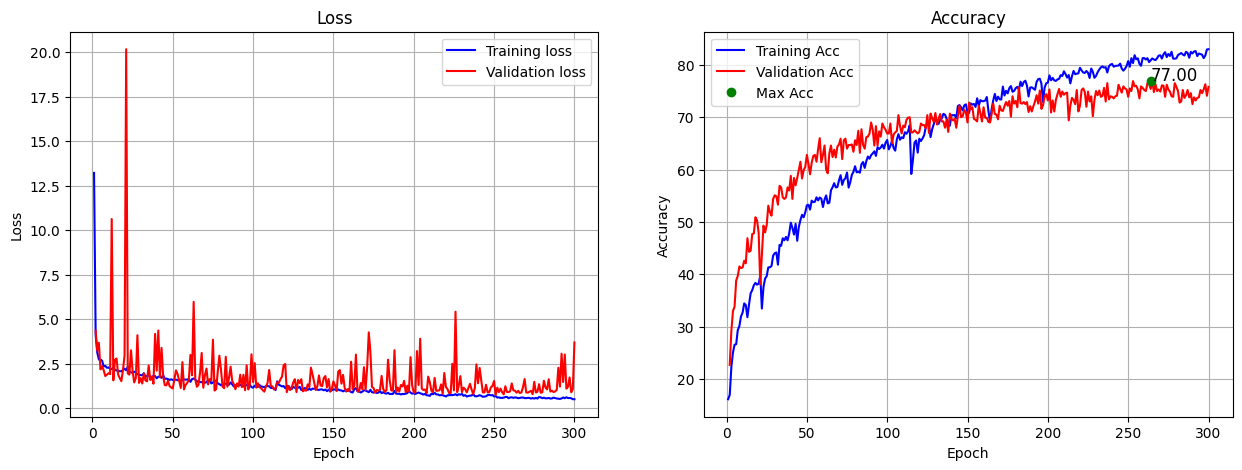

In [65]:
plot_training_history(results_dict_2, params)

# Adam

In [66]:
params['optimizer'] = 'Adam'

In [67]:
results_dict_3 = fitness_calculation(id_num="job_2", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
results_dict_3["best_accuracy"]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training Fitness Scheme:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch [2/300] - Training loss: 4.48134394349723 - Validation loss: 2.9279487133026123 - Validation accuracy: 24.875%
Epoch [3/300] - Training loss: 3.2739003608966697 - Validation loss: 2.177992105484009 - Validation accuracy: 31.375%
Epoch [4/300] - Training loss: 2.867996470681552 - Validation loss: 2.990112066268921 - Validation accuracy: 32.625%
Epoch [5/300] - Training loss: 2.6878210676127465 - Validation loss: 3.5260064601898193 - Validation accuracy: 35.625%
Epoch [6/300] - Training loss: 2.465160271217083 - Validation loss: 4.357522487640381 - Validation accuracy: 36.5%
Epoch [7/300] - Training loss: 2.503400580636386 - Validation loss: 14.005467414855957 - Validation accuracy: 32.375%
Epoch [8/300] - Training loss: 2.6051750676385286 - Validation loss: 1.8739309310913086 - Validation accuracy: 37.0%
Epoch [9/300] - Training loss: 2.341636661825509 - Validation loss: 3.5216689109802246 - Validation accuracy: 39.375%
Epoch [10/300] - Training loss: 2.508256402508966 - Validatio

72.375

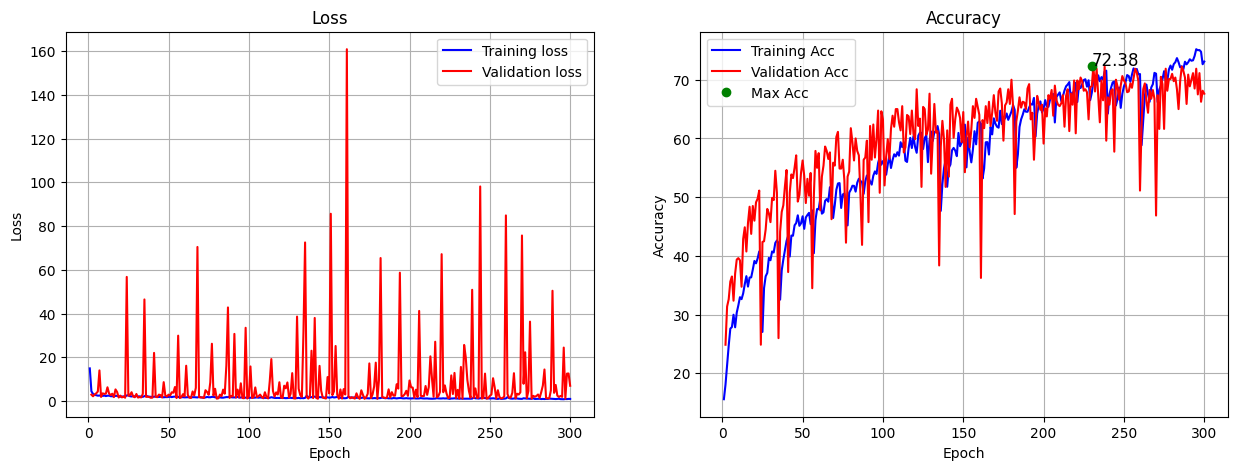

In [68]:
plot_training_history(results_dict_3, params)